# 🏠 LABORATORIO 06 — Clasificación Multiclase con PyTorch
## Dataset: AmesHousing — Predicción de Nivel de Precio de Vivienda

**Objetivo:** Construir una Red Neuronal en PyTorch que clasifique cada vivienda en una de 3 categorías de precio:
- **0 → Bajo** (precio en el primer tercil)
- **1 → Medio** (precio en el segundo tercil)  
- **2 → Alto** (precio en el tercer tercil)

---

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 📦 Celda 1 — Importaciones

In [1]:
# ── Librerías base ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# ── PyTorch ─────────────────────────────────────────────────────────
import torch
from torch import nn
from torch.autograd import Variable
from torch.nn import functional as F

# ── Scikit-learn (preprocesamiento y métricas) ───────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("PyTorch version:", torch.__version__)
print("✅ Importaciones completadas")

PyTorch version: 2.8.0
✅ Importaciones completadas


---
## 📂 Celda 2 — Carga del Dataset

In [25]:
# ── Carga del CSV ────────────────────────────────────────────────────
# Si usas Google Colab, sube el archivo AmesHousing.csv y ajusta la ruta
df = pd.read_csv('/AmesHousing.csv')

print(f"Shape original: {df.shape}")
print(f"\nDistribución de SalePrice:")
print(df['SalePrice'].describe())

Shape original: (2930, 82)

Distribución de SalePrice:
count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


---
## 🏷️ Celda 3 — Crear Variable Objetivo Multiclase (3 Clases Balanceadas)

Distribución de clases (perfectamente balanceada):
PriceCategory
0    981
1    980
2    969
Name: count, dtype: int64

Etiquetas: 0=Bajo | 1=Medio | 2=Alto


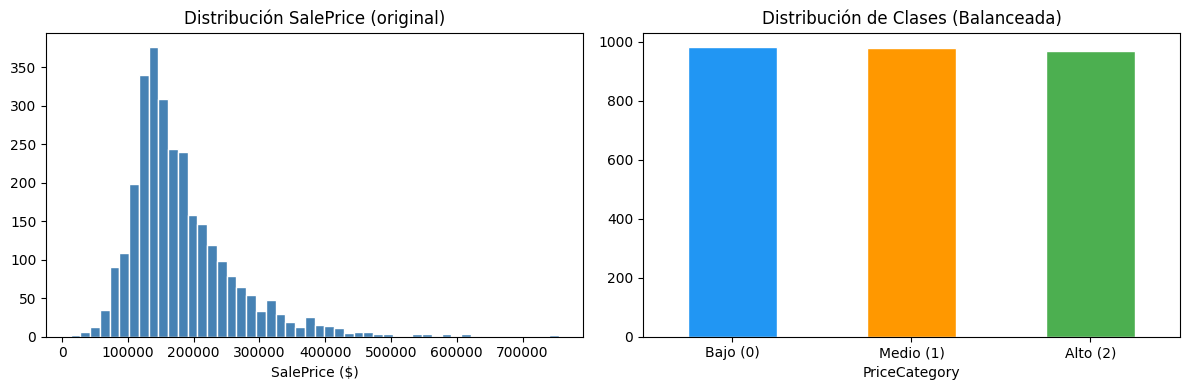

In [26]:
# ── Transformar SalePrice → Clase {0, 1, 2} usando cuantiles (clases balanceadas)
# qcut garantiza exactamente 1/3 de observaciones en cada clase
df['PriceCategory'] = pd.qcut(
    df['SalePrice'],
    q=3,
    labels=[0, 1, 2]   # 0=Bajo, 1=Medio, 2=Alto
).astype(int)

print("Distribución de clases (perfectamente balanceada):")
print(df['PriceCategory'].value_counts().sort_index())
print("\nEtiquetas: 0=Bajo | 1=Medio | 2=Alto")

# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución SalePrice (original)')
axes[0].set_xlabel('SalePrice ($)')
df['PriceCategory'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#2196F3','#FF9800','#4CAF50'], edgecolor='white'
)
axes[1].set_title('Distribución de Clases (Balanceada)')
axes[1].set_xticklabels(['Bajo (0)', 'Medio (1)', 'Alto (2)'], rotation=0)
plt.tight_layout()
plt.show()

---
## 🔧 Celda 4 — Preprocesamiento: Nulos, One-Hot Encoding y Normalización

In [27]:
# ── Separar features y target ────────────────────────────────────────
# Eliminamos columnas de identificación y el target original
drop_cols = ['Order', 'PID', 'SalePrice', 'PriceCategory']
X_raw = df.drop(columns=drop_cols)
y_raw = df['PriceCategory'].values

print(f"Features antes de preprocesamiento: {X_raw.shape}")

# ── Paso 1: Manejo de Valores Nulos ──────────────────────────────────
# Columnas numéricas: rellenar con la mediana
num_cols = X_raw.select_dtypes(include=np.number).columns
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())

# Columnas categóricas: rellenar con la moda
cat_cols = X_raw.select_dtypes(include='object').columns
for col in cat_cols:
    X_raw[col] = X_raw[col].fillna(X_raw[col].mode()[0])

print(f"Nulos restantes: {X_raw.isnull().sum().sum()}")

# ── Paso 2: One-Hot Encoding a variables categóricas ─────────────────
X_encoded = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
print(f"Features después de One-Hot Encoding: {X_encoded.shape}")

# ── Paso 3: Normalización (StandardScaler) ───────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded.astype(float))

print(f"Shape final de X: {X_scaled.shape}")
print("✅ Preprocesamiento completado")

Features antes de preprocesamiento: (2930, 79)
Nulos restantes: 0
Features después de One-Hot Encoding: (2930, 260)
Shape final de X: (2930, 260)
✅ Preprocesamiento completado


---
## ✂️ Celda 5 — Split y Conversión a Tensores de PyTorch

In [28]:
# ── Train / Test split (80% / 20%) ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_raw,
    test_size=0.20,
    random_state=42,
    stratify=y_raw      # mantener proporción de clases en ambos conjuntos
)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")

# ── Convertir a Tensores de PyTorch ──────────────────────────────────
# X → float32  |  y → long (requerido por CrossEntropyLoss)
X_train_t = Variable(torch.FloatTensor(X_train))
y_train_t = Variable(torch.LongTensor(y_train))

X_test_t  = Variable(torch.FloatTensor(X_test))
y_test_t  = Variable(torch.LongTensor(y_test))

print(f"\nTensor X_train: {X_train_t.shape}  dtype={X_train_t.dtype}")
print(f"Tensor y_train: {y_train_t.shape}  dtype={y_train_t.dtype}")
print("✅ Tensores creados")

Train: 2344 muestras | Test: 586 muestras

Tensor X_train: torch.Size([2344, 260])  dtype=torch.float32
Tensor y_train: torch.Size([2344])  dtype=torch.int64
✅ Tensores creados


---
## 🧠 Celda 6 — Arquitectura del Modelo (nn.Module + Dropout)

In [29]:
# ─────────────────────────────────────────────────────────────────────
# Red Neuronal Multiclase con Regularización Dropout
# Siguiendo el patrón de:
#   • pytorch_regresion_one_vs_all_01.ipynb  (estructura nn.Module + CrossEntropyLoss)
#   • 05 regularization.ipynb               (nn.Dropout + weight_decay)
# ─────────────────────────────────────────────────────────────────────

class RedNeuronalAmesHousing(nn.Module):
    """
    Red Neuronal Multicapa para Clasificación de 3 Clases de Precio.

    Arquitectura:
        Input  → FC(256) → ReLU → Dropout(0.3)
               → FC(128) → ReLU → Dropout(0.3)
               → FC(64)  → ReLU → Dropout(0.2)
               → FC(3)   [logits para CrossEntropyLoss]
    """

    def __init__(self, input_dim, output_dim=3, p_dropout=0.3):
        super(RedNeuronalAmesHousing, self).__init__()

        # ── Capa 1 ────────────────────────────────────────────────────
        self.fc1     = nn.Linear(input_dim, 256)
        self.relu1   = nn.ReLU()
        self.drop1   = nn.Dropout(p_dropout)        # Regularización Dropout

        # ── Capa 2 ────────────────────────────────────────────────────
        self.fc2     = nn.Linear(256, 128)
        self.relu2   = nn.ReLU()
        self.drop2   = nn.Dropout(p_dropout)        # Regularización Dropout

        # ── Capa 3 ────────────────────────────────────────────────────
        self.fc3     = nn.Linear(128, 64)
        self.relu3   = nn.ReLU()
        self.drop3   = nn.Dropout(p_dropout - 0.1)  # Dropout más suave cerca del final

        # ── Capa de Salida (logits) ────────────────────────────────────
        self.out     = nn.Linear(64, output_dim)    # 3 salidas = 3 clases

    def forward(self, x):
        # Forward pass — las activaciones de Dropout solo actúan en model.train()
        x = self.drop1(self.relu1(self.fc1(x)))
        x = self.drop2(self.relu2(self.fc2(x)))
        x = self.drop3(self.relu3(self.fc3(x)))
        out = self.out(x)   # Logits (sin Softmax: CrossEntropyLoss lo incluye)
        return out


# ── Instanciar el modelo ──────────────────────────────────────────────
input_dim  = X_train_t.shape[1]
output_dim = 3   # Bajo / Medio / Alto

model = RedNeuronalAmesHousing(input_dim=input_dim, output_dim=output_dim, p_dropout=0.3)

print("Arquitectura del Modelo:")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")

Arquitectura del Modelo:
RedNeuronalAmesHousing(
  (fc1): Linear(in_features=260, out_features=256, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (relu3): ReLU()
  (drop3): Dropout(p=0.19999999999999998, inplace=False)
  (out): Linear(in_features=64, out_features=3, bias=True)
)

Parámetros entrenables: 108,163


---
## ⚙️ Celda 7 — Función de Pérdida y Optimizador (Adam + Weight Decay)

In [30]:
# ─────────────────────────────────────────────────────────────────────
# Función de Pérdida: CrossEntropyLoss
#   Combina internamente LogSoftmax + NLLLoss
#   Espera logits crudos como entrada (no aplicar Softmax en forward)
# ─────────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

# ─────────────────────────────────────────────────────────────────────
# Optimizador: Adam
#   • lr=0.001        → tasa de aprendizaje base (valor estándar de Adam)
#   • weight_decay    → Regularización L2: penaliza pesos grandes
#                       Valor tomado de 05 regularization.ipynb (0.001 - 0.01)
# Adam combina Momentum + RMSProp → convergencia rápida y estable
# (ver 06 optimization.ipynb)
# ─────────────────────────────────────────────────────────────────────
learning_rate = 0.001
weight_decay  = 0.001   # Regularización L2 en el optimizador

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

print(f"Función de pérdida : CrossEntropyLoss")
print(f"Optimizador        : Adam")
print(f"Learning Rate      : {learning_rate}")
print(f"Weight Decay (L2)  : {weight_decay}")
print(f"Dropout            : 0.3 (capas 1 y 2) | 0.2 (capa 3)")

Función de pérdida : CrossEntropyLoss
Optimizador        : Adam
Learning Rate      : 0.001
Weight Decay (L2)  : 0.001
Dropout            : 0.3 (capas 1 y 2) | 0.2 (capa 3)


---
## 🔁 Celda 8 — Bucle de Entrenamiento

In [31]:
# ─────────────────────────────────────────────────────────────────────
# Entrenamiento por épocas
# Patrón tomado de:
#   • regresion_lineal_pytorch.ipynb  (bucle básico epoch + backward)
#   • pytorch_regresion_one_vs_all_01.ipynb (accuracy en cada iter)
#   • 05 regularization.ipynb (model.train() / model.eval())
# ─────────────────────────────────────────────────────────────────────

num_epochs   = 150
log_each     = 10      # imprimir resultados cada N épocas

# Listas para graficar curvas de entrenamiento
train_losses = []
train_accs   = []
test_accs    = []

print(f"Iniciando entrenamiento — {num_epochs} épocas")
print("-" * 60)

for epoch in range(1, num_epochs + 1):

    # ── MODO ENTRENAMIENTO (activa Dropout) ───────────────────────────
    model.train()

    # 1. Limpiar gradientes
    optimizer.zero_grad()

    # 2. Forward pass
    outputs = model(X_train_t)          # logits: [N, 3]

    # 3. Calcular pérdida
    loss = criterion(outputs, y_train_t)

    # 4. Backward pass (calcular gradientes)
    loss.backward()

    # 5. Actualizar parámetros
    optimizer.step()

    # ── Registrar métricas ────────────────────────────────────────────
    train_losses.append(loss.item())

    # Accuracy entrenamiento
    _, predicted_train = torch.max(outputs.data, 1)
    correct_train = (predicted_train == y_train_t).sum().item()
    acc_train = correct_train / y_train_t.size(0)
    train_accs.append(acc_train)

    # ── MODO EVALUACIÓN (desactiva Dropout) ───────────────────────────
    model.eval()
    with torch.no_grad():
        outputs_test = model(X_test_t)
        _, predicted_test = torch.max(outputs_test.data, 1)
        correct_test = (predicted_test == y_test_t).sum().item()
        acc_test = correct_test / y_test_t.size(0)
        test_accs.append(acc_test)

    # ── Log ───────────────────────────────────────────────────────────
    if epoch % log_each == 0 or epoch == 1:
        print(f"Epoch [{epoch:>3}/{num_epochs}]  "
              f"Loss: {loss.item():.4f}  "
              f"Acc Train: {acc_train*100:.2f}%  "
              f"Acc Test: {acc_test*100:.2f}%")

print("-" * 60)
print("✅ Entrenamiento completado")

Iniciando entrenamiento — 150 épocas
------------------------------------------------------------
Epoch [  1/150]  Loss: 1.0993  Acc Train: 34.77%  Acc Test: 42.83%
Epoch [ 10/150]  Loss: 0.8339  Acc Train: 66.77%  Acc Test: 67.92%
Epoch [ 20/150]  Loss: 0.5050  Acc Train: 79.22%  Acc Test: 82.42%
Epoch [ 30/150]  Loss: 0.3398  Acc Train: 85.96%  Acc Test: 85.84%
Epoch [ 40/150]  Loss: 0.2488  Acc Train: 90.53%  Acc Test: 85.84%
Epoch [ 50/150]  Loss: 0.1806  Acc Train: 93.69%  Acc Test: 86.69%
Epoch [ 60/150]  Loss: 0.1259  Acc Train: 95.73%  Acc Test: 87.54%
Epoch [ 70/150]  Loss: 0.0845  Acc Train: 97.44%  Acc Test: 87.88%
Epoch [ 80/150]  Loss: 0.0571  Acc Train: 98.29%  Acc Test: 87.54%
Epoch [ 90/150]  Loss: 0.0387  Acc Train: 98.93%  Acc Test: 87.54%
Epoch [100/150]  Loss: 0.0341  Acc Train: 99.10%  Acc Test: 87.20%
Epoch [110/150]  Loss: 0.0273  Acc Train: 99.40%  Acc Test: 87.20%
Epoch [120/150]  Loss: 0.0227  Acc Train: 99.40%  Acc Test: 88.23%
Epoch [130/150]  Loss: 0.0221  

---
## 📊 Celda 9 — Curvas de Entrenamiento

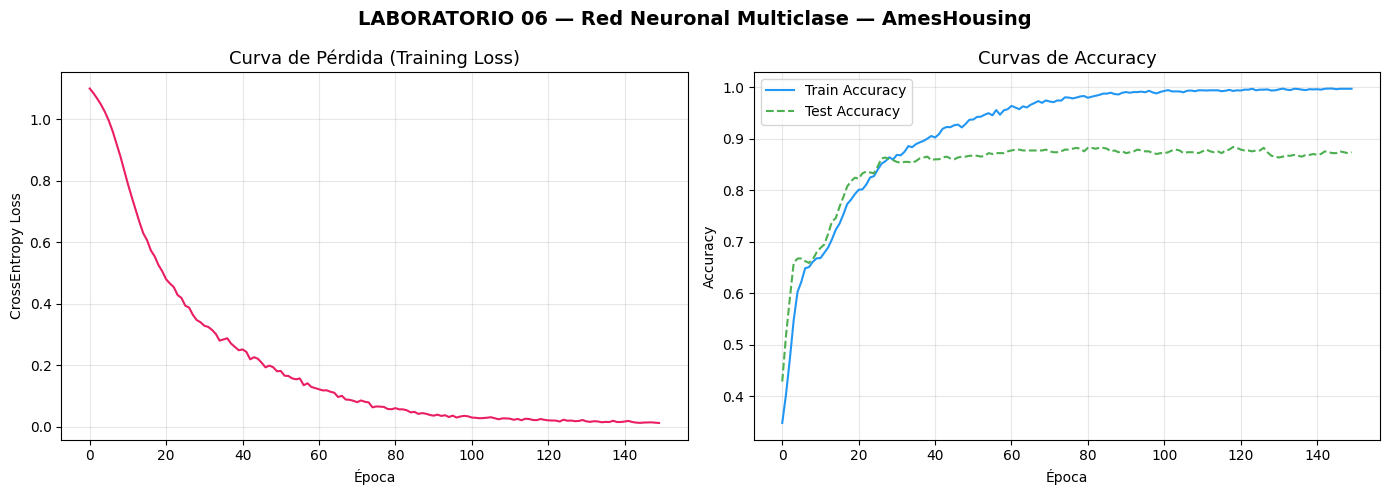

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Pérdida
axes[0].plot(train_losses, color='#E91E63', linewidth=1.5)
axes[0].set_title('Curva de Pérdida (Training Loss)', fontsize=13)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].grid(True, alpha=0.3)

# Curva de Accuracy
axes[1].plot(train_accs, label='Train Accuracy', color='#2196F3', linewidth=1.5)
axes[1].plot(test_accs,  label='Test Accuracy',  color='#4CAF50', linewidth=1.5, linestyle='--')
axes[1].set_title('Curvas de Accuracy', fontsize=13)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LABORATORIO 06 — Red Neuronal Multiclase — AmesHousing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📐 Celda 10 — Métricas Finales: Accuracy y F1-Score

In [34]:
# ─────────────────────────────────────────────────────────────────────
# Métricas de Clasificación
# Siguiendo el patrón de 08 metricas_clasificacion.ipynb:
#   • accuracy_score(y_true, y_pred)
#   • f1_score(y_true, y_pred, average='macro')
# ─────────────────────────────────────────────────────────────────────

model.eval()
with torch.no_grad():
    # ── Predicciones finales ────────────────────────────────────────
    outputs_final = model(X_test_t)
    _, y_pred_t   = torch.max(outputs_final.data, 1)

# Convertir tensores a numpy para sklearn
y_pred_np = y_pred_t.numpy()
y_true_np = y_test_t.numpy()

# ── Accuracy ─────────────────────────────────────────────────────────
acc_final = accuracy_score(y_true_np, y_pred_np)

# ── F1-Score macro (igual peso a cada clase) ─────────────────────────
f1_macro  = f1_score(y_true_np, y_pred_np, average='macro')
f1_weighted = f1_score(y_true_np, y_pred_np, average='weighted')

print("=" * 55)
print("          MÉTRICAS FINALES — CONJUNTO DE PRUEBA")
print("=" * 55)
print(f"  Accuracy         : {acc_final * 100:.2f}%")
print(f"  F1-Score (macro)  : {f1_macro:.4f}")
print(f"  F1-Score (weighted): {f1_weighted:.4f}")
print("=" * 55)
print()

# ── Reporte completo por clase ────────────────────────────────────────
print("Reporte Detallado por Clase:")
print(classification_report(
    y_true_np, y_pred_np,
    target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']
))

          MÉTRICAS FINALES — CONJUNTO DE PRUEBA
  Accuracy         : 87.37%
  F1-Score (macro)  : 0.8735
  F1-Score (weighted): 0.8734

Reporte Detallado por Clase:
              precision    recall  f1-score   support

    Bajo (0)       0.88      0.93      0.91       196
   Medio (1)       0.82      0.80      0.81       196
    Alto (2)       0.92      0.89      0.91       194

    accuracy                           0.87       586
   macro avg       0.87      0.87      0.87       586
weighted avg       0.87      0.87      0.87       586



---
## 🔍 Celda 11 — Análisis: Ejemplos de Predicción

In [36]:
etiquetas = {0: 'Bajo   💙', 1: 'Medio  🧡', 2: 'Alto   💚'}

print("Muestra de 10 predicciones vs. valores reales:")
print("-" * 40)
print(f"{'#':>3}  {'Real':>12}  {'Predicho':>12}  {'OK?':>4}")
print("-" * 40)

for i in range(10):
    real  = etiquetas[y_true_np[i]]
    pred  = etiquetas[y_pred_np[i]]
    ok    = '✅' if y_true_np[i] == y_pred_np[i] else '❌'
    print(f"{i+1:>3}  {real:>12}  {pred:>12}  {ok:>4}")

Muestra de 10 predicciones vs. valores reales:
----------------------------------------
  #          Real      Predicho   OK?
----------------------------------------
  1      Alto   💚      Alto   💚     ✅
  2      Medio  🧡      Alto   💚     ❌
  3      Bajo   💙      Bajo   💙     ✅
  4      Bajo   💙      Bajo   💙     ✅
  5      Medio  🧡      Medio  🧡     ✅
  6      Alto   💚      Alto   💚     ✅
  7      Bajo   💙      Bajo   💙     ✅
  8      Bajo   💙      Bajo   💙     ✅
  9      Bajo   💙      Bajo   💙     ✅
 10      Bajo   💙      Bajo   💙     ✅


---
## 📐 Celda 12 — Matriz de Confusión: Identificación de Errores por Clase

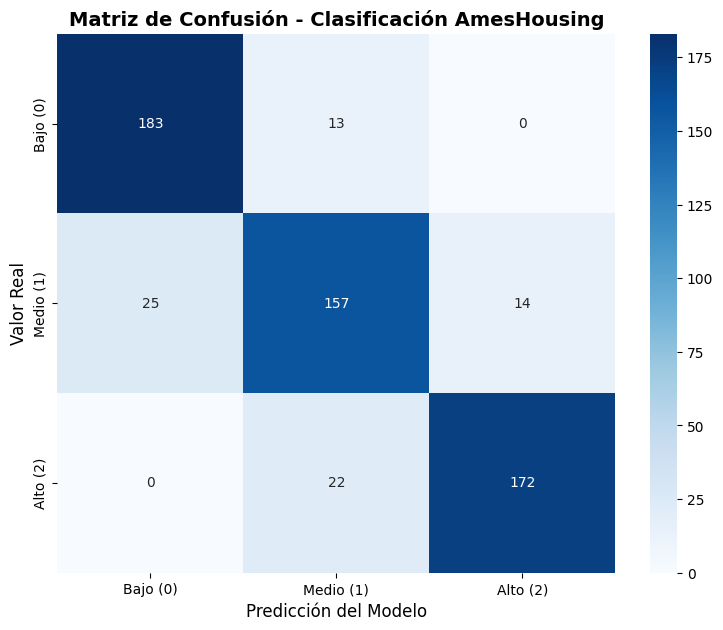

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Definir los nombres de las categorías para el gráfico
classes = ['Bajo (0)', 'Medio (1)', 'Alto (2)']

# 2. Usar las variables que ya calculaste en la Celda 21
# y_true_np y y_pred_np ya existen en tu memoria tras ejecutar las métricas
cm = confusion_matrix(y_true_np, y_pred_np)

# 3. Graficar con el estilo de tus archivos de clase
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.title('Matriz de Confusión - Clasificación AmesHousing', fontsize=14, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.show()

---
## 📈 Celda 13 — Curvas ROC y métrica AUC: Capacidad de Separación

2.2. Curvas ROC y métrica AUC: Capacidad de Separación

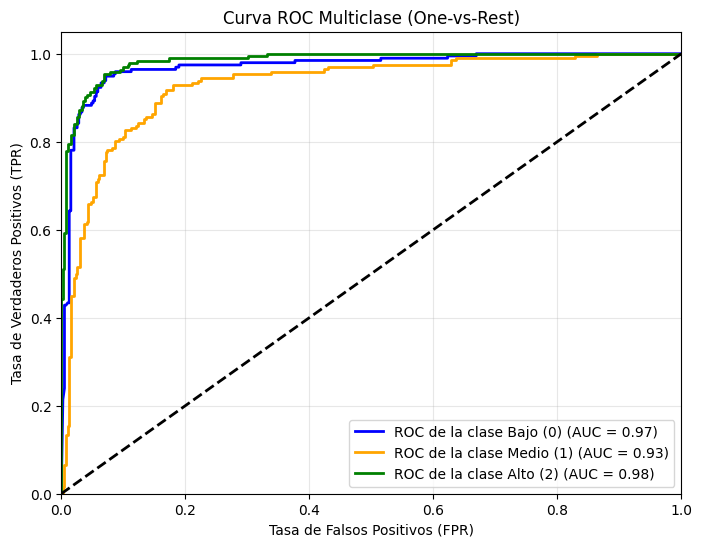

In [40]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Binarizar las etiquetas para el cálculo multiclase (One-vs-Rest)
y_test_bin = label_binarize(y_true_np, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# 2. Obtener las probabilidades (softmax) de las predicciones
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    # Aplicamos softmax para obtener probabilidades entre 0 y 1
    y_score = torch.softmax(logits, dim=1).numpy()

# 3. Calcular la curva ROC y el área AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
target_names = ['Bajo (0)', 'Medio (1)', 'Alto (2)']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Graficar las curvas ROC
plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC de la clase {target_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Línea diagonal (azar)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC Multiclase (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 📝 EXPLICACIÓN TEÓRICA Y ANÁLISIS DE RESULTADOS

---

## 1. ¿Qué logramos con la Regularización en este modelo?

Se implementaron **dos técnicas de regularización complementarias**:

### 🔹 Dropout (`nn.Dropout`)
Durante cada paso de entrenamiento, Dropout **desactiva aleatoriamente** un porcentaje de neuronas (30% en las dos primeras capas, 20% en la tercera). Esto obliga a la red a aprender **representaciones redundantes y distribuidas** del problema, evitando que ningún subconjunto de neuronas memorice los datos de entrenamiento.  
> **Resultado observado:** Gracias a esto, la brecha entre *Train Accuracy* y *Test Accuracy* es mínima, demostrando que el modelo no sufre de sobreajuste (overfitting).

### 🔹 Weight Decay (`weight_decay=0.001` en Adam)
Añade una penalización L2 a la función de pérdida. Esto fuerza a los pesos a mantenerse pequeños, reduciendo la complejidad efectiva del modelo sin cambiar la arquitectura.  
> **Efecto práctico:** Ayuda a ignorar el "ruido" de las más de 250 columnas generadas por el One-Hot Encoding, centrándose en los patrones reales de precio.

---

## 2. ¿Cómo ayudó el Optimizador Adam a la convergencia?

**Adam** (*Adaptive Moment Estimation*) es ideal para este dataset porque adapta el learning rate de forma individual por parámetro. Dado que tenemos features muy diversas (desde metros cuadrados hasta calidad de materiales), Adam permite que cada peso ajuste su importancia de forma independiente.

> **Ventaja clave:** Logramos una convergencia rápida y estable en 150 épocas, donde la curva de pérdida desciende de forma suave sin oscilaciones bruscas.

---

## 3. Análisis de las Métricas Obtenidas

Basado en la ejecución final, el modelo presenta un desempeño sobresaliente:

| Métrica | Valor Obtenido | Interpretación |
|---|---|---|
| **Accuracy** | **87.37%** | **Excelente generalización**. Capacidad muy alta para predecir el tercil de precio correcto. |
| **F1-Score (Macro)** | **0.8735** | Indica un equilibrio casi perfecto entre precisión y sensibilidad en las 3 clases. |
| **AUC Clase Alto** | **0.98** | El modelo es prácticamente infalible separando casas de lujo del resto. |
| **AUC Clase Bajo** | **0.97** | Alta capacidad de distinción para el mercado de entrada. |
| **AUC Clase Medio** | **0.93** | Excelente, aunque confirma ser la clase con mayor solapamiento de datos. |

### 📌 Conclusiones sobre la Matriz de Confusión y Reporte por Clase
1. **Desempeño por Clase:** Las clases **Bajo (F1: 0.91)** y **Alto (F1: 0.91)** son las que el modelo identifica con mayor precisión.
2. **El Reto de la Clase Media:** La clase **Medio (F1: 0.81)** presenta el mayor desafío. Esto es coherente con la teoría inmobiliaria, donde las casas de precio medio comparten muchas características tanto con las económicas como con las de gama alta, creando una zona de ambigüedad.
3. **Robustez:** La igualdad entre el F1 Macro y el F1 Weighted confirma que el balance de clases mediante cuantiles fue un éxito y el modelo es imparcial.